In [ ]:
# Section 1: Import Libraries
import kagglehub
import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import plot_model
from skimage import exposure
from skimage.filters import gaussian, sobel
from scipy.ndimage import convolve

In [ ]:
# Section 2: Download and Prepare Dataset
# Download dataset
xhlulu_140k_real_and_fake_faces_path = kagglehub.dataset_download('xhlulu/140k-real-and-fake-faces')
print('Data source import complete.')

100%|██████████| 3.75G/3.75G [02:50<00:00, 23.6MB/s]

Extracting files...


Data source import complete.


In [ ]:
# Move dataset to new path
new_path = "/content/Dataset"
if not os.path.exists(new_path):
    os.makedirs(new_path)
os.rename(xhlulu_140k_real_and_fake_faces_path, new_path)
print("Dataset moved to:", new_path)

Dataset moved to: /content/Dataset


In [ ]:
# Define directories
train_dir = '/content/Dataset/real_vs_fake/real-vs-fake/train'
val_dir = '/content/Dataset/real_vs_fake/real-vs-fake/valid'
test_dir = '/content/Dataset/real_vs_fake/real-vs-fake/test'

In [ ]:
print("Train_dir Subfolders:", os.listdir(train_dir))
print("Valid_dir Subfolders:", os.listdir(val_dir))
print("Test_dir Subfolders:", os.listdir(test_dir))

Train_dir Subfolders: ['real', 'fake']
Valid_dir Subfolders: ['real', 'fake']
Test_dir Subfolders: ['real', 'fake']


In [ ]:
# Section 3: Define Image Enhancement Functions
# Define a kernel for sharpening
sharpening_kernel = np.array([[0, -1, 0],
                              [-1, 5, -1],
                              [0, -1, 0]])

# Function to apply kernel filtering to each channel of the image
def apply_kernel_filter(img):
    # Apply the kernel to each channel separately
    filtered_channels = []
    for channel in range(img.shape[-1]):  # Loop through each channel (e.g., R, G, B)
        filtered_channel = convolve(img[:, :, channel], sharpening_kernel, mode='reflect')
        filtered_channels.append(filtered_channel)

    # Stack the filtered channels back into a single image
    filtered_img = np.stack(filtered_channels, axis=-1)
    return filtered_img

# Function to apply histogram equalization
def apply_histogram_equalization(img):
    return exposure.equalize_hist(img)

# Function to enhance an image
def enhance_image(img):
    img = apply_kernel_filter(img)  # Apply sharpening
    img = apply_histogram_equalization(img)  # Apply histogram equalization
    return img

/usr/local/lib/python3.11/dist-packages/skimage/_shared/utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


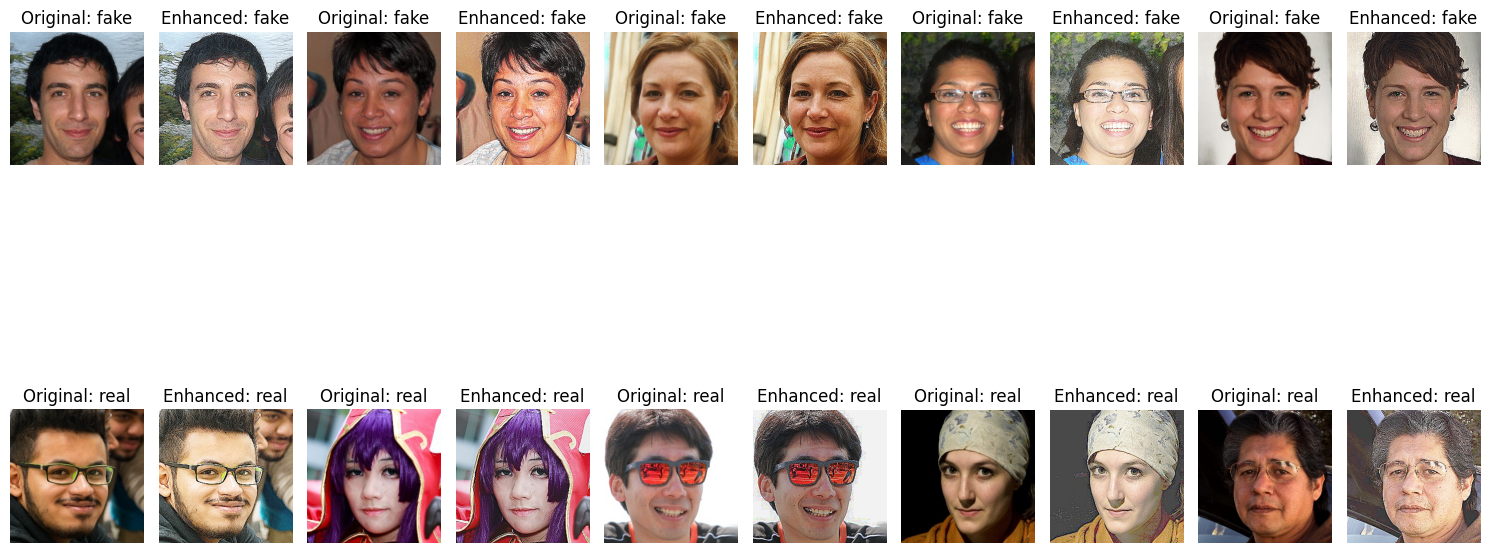

In [ ]:
# Section 4: Visualize Original and Enhanced Images
# Define class names
class_names = ['fake', 'real']
num_images = 5  # Number of images to display

# Plot original and enhanced images
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)
    images = os.listdir(class_dir)
    selected_images = random.sample(images, num_images)  # Randomly select images

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path) / 255.0  # Normalize image

        # Plot original image
        plt.subplot(len(class_names), num_images * 2, i * (num_images * 2) + 2 * j + 1)
        plt.imshow(img)
        plt.title(f'Original: {class_name}')
        plt.axis('off')

        # Enhance image
        enhanced_img = enhance_image(img)

        # Plot enhanced image
        plt.subplot(len(class_names), num_images * 2, i * (num_images * 2) + 2 * j + 2)
        plt.imshow(enhanced_img)
        plt.title(f'Enhanced: {class_name}')
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Section 5: Apply Enhancements to Dataset
# Create directories for enhanced dataset
enhanced_train_dir = '/content/Dataset/enhanced_train'
enhanced_val_dir = '/content/Dataset/enhanced_val'
enhanced_test_dir = '/content/Dataset/enhanced_test'


In [ ]:
os.makedirs(enhanced_train_dir, exist_ok=True)
os.makedirs(enhanced_val_dir, exist_ok=True)
os.makedirs(enhanced_test_dir, exist_ok=True)

In [ ]:
# Function to enhance and save images
def enhance_and_save_dataset(original_dir, enhanced_dir):
    for class_name in class_names:
        class_dir = os.path.join(original_dir, class_name)
        enhanced_class_dir = os.path.join(enhanced_dir, class_name)
        os.makedirs(enhanced_class_dir, exist_ok=True)

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = mpimg.imread(img_path) / 255.0  # Normalize image
            enhanced_img = enhance_image(img)  # Apply enhancement
            enhanced_img_path = os.path.join(enhanced_class_dir, img_name)
            plt.imsave(enhanced_img_path, enhanced_img)

# Apply enhancements to train, validation, and test datasets
enhance_and_save_dataset(train_dir, enhanced_train_dir)
enhance_and_save_dataset(val_dir, enhanced_val_dir)
enhance_and_save_dataset(test_dir, enhanced_test_dir)

print("Dataset enhancement complete.")

Dataset enhancement complete.


In [ ]:
# Section 6: Data Generators for Enhanced Dataset
# Image data generators for enhanced dataset
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)
target_size = (256, 256)
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    enhanced_train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    enhanced_val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    enhanced_test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print("Training class distribution:", train_generator.class_indices)
print("Validation class distribution:", val_generator.class_indices)


Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Training class distribution: {'fake': 0, 'real': 1}
Validation class distribution: {'fake': 0, 'real': 1}


In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import callbacks

# Load ResNet50 with fine-tuning enabled
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
for layer in base_model.layers[:-20]:  # Fine-tune last 20 layers
    layer.trainable = False

# Define model with additional Dense layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),  # New layer added here
    layers.Dropout(0.2),  # Optional: Add dropout for regularization
    layers.Dense(32, activation='relu'),  # First additional layer
    layers.Dropout(0.1),  # Optional: Add dropout for regularization
    layers.Dense(16, activation='relu'),  # Second additional layer
    layers.Dropout(0.1),  # Optional: Add dropout for regularization
    layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 8, 8, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,811,905 (94.65 MB)

 Trainable params: 10,155,521 (38.74 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [ ]:
# Section 8: Train the Model
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 276s 158ms/step - accuracy: 0.6330 - loss: 0.6321 - val_accuracy: 0.5006 - val_loss: 1.6168
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 223s 143ms/step - accuracy: 0.7783 - loss: 0.4778 - val_accuracy: 0.6703 - val_loss: 0.5600
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 223s 143ms/step - accuracy: 0.8054 - loss: 0.4315 - val_accuracy: 0.5113 - val_loss: 2.1465
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 223s 143ms/step - accuracy: 0.8268 - loss: 0.3908 - val_accuracy: 0.6998 - val_loss: 0.5218
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 224s 143ms/step - accuracy: 0.8405 - loss: 0.3681 - val_accuracy: 0.7335 - val_loss: 0.5875
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 224s 143ms/step - accuracy: 0.8493 - loss: 0.3506 - val_accuracy: 0.6439 - val_loss: 0.9518
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 223s 143ms/step - accuracy: 0.8556 - loss: 0.3362 - val_accuracy: 0.6710 - val_loss: 0.5720
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 223s 143ms/s

In [ ]:
# Save the model
model.save('/content/model/Resnet_model_100e.h5')

In [ ]:
# Section 9: Evaluate the Model
# Evaluate the model
test_metrics = model.evaluate(test_generator)
print("Test metrics:", test_metrics[1])

test_metrics = model.evaluate(train_generator)
print("Train metrics:", test_metrics[1])


313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.9302 - loss: 0.2577
Test metrics: 0.8143500089645386
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 178s 114ms/step - accuracy: 0.8719 - loss: 0.2822
Train metrics: 0.8708800077438354


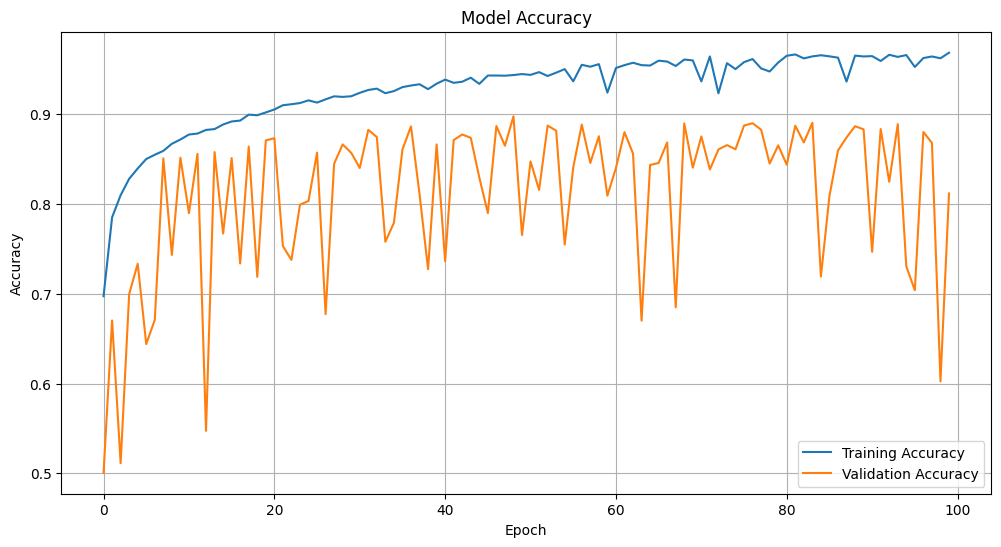

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

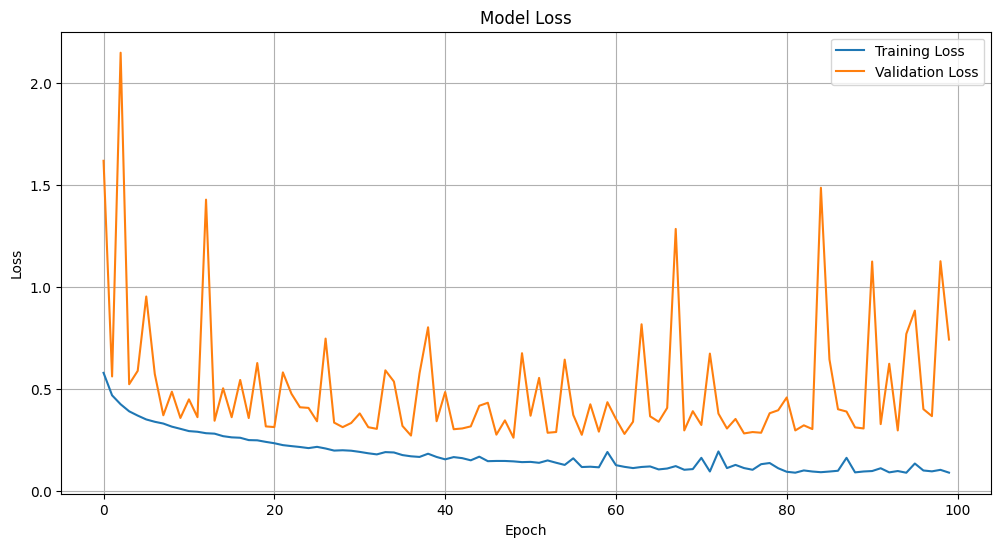

In [ ]:
# Plot loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step
              precision    recall  f1-score   support

        fake       0.74      0.98      0.84     10000
        real       0.97      0.65      0.78     10000

    accuracy                           0.81     20000
   macro avg       0.85      0.81      0.81     20000
weighted avg       0.85      0.81      0.81     20000



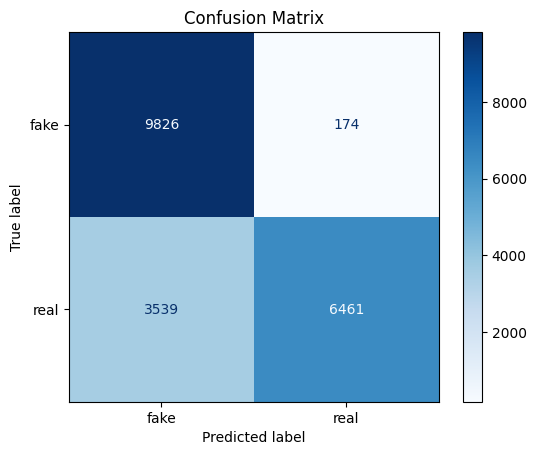

In [ ]:
# Section 10: Make Predictions and Confusion Matrix
# Make predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.where(predictions > 0.5, 1, 0)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


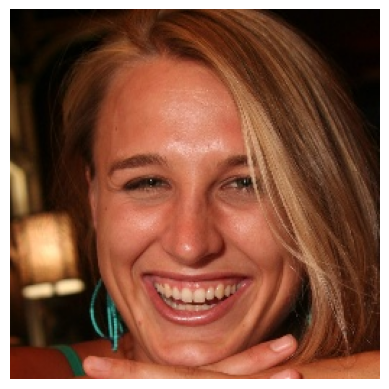

The model predicts this image is 'real' with a confidence of 99.12%.
The model predicts this image is 'fake' with a confidence of 0.88%.


In [ ]:
# Section 11: Test with a Single Image
# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

# Test with an image
img_path = '/content/Dataset/real_vs_fake/real-vs-fake/test/real/00001.jpg'
img, img_array = load_and_preprocess_image(img_path, target_size)
prediction = model.predict(img_array)
real_confidence = prediction[0][0] * 100
fake_confidence = (1 - prediction[0][0]) * 100
plt.imshow(img)
plt.axis('off')
plt.show()
print(f"The model predicts this image is 'real' with a confidence of {real_confidence:.2f}%.")
print(f"The model predicts this image is 'fake' with a confidence of {fake_confidence:.2f}%.")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


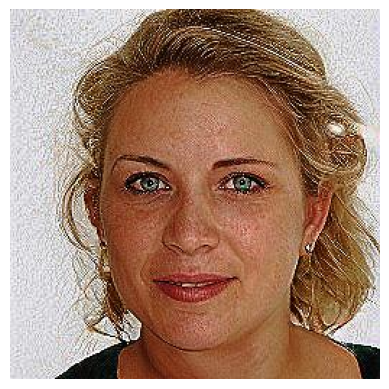

Image: RZLBM57834.jpg
Model Prediction: 'Real' confidence = 0.31%
Model Prediction: 'Fake' confidence = 99.69%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


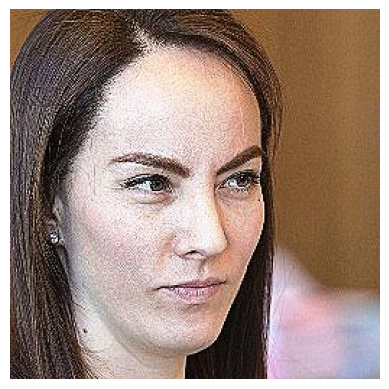

Image: 50790.jpg
Model Prediction: 'Real' confidence = 24.40%
Model Prediction: 'Fake' confidence = 75.60%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


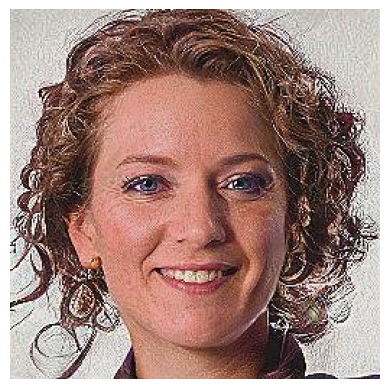

Image: ZMOP09Z3U6.jpg
Model Prediction: 'Real' confidence = 0.00%
Model Prediction: 'Fake' confidence = 100.00%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


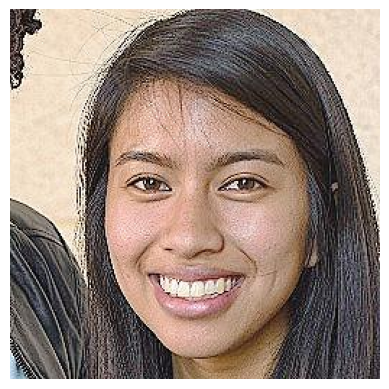

Image: 61507.jpg
Model Prediction: 'Real' confidence = 49.99%
Model Prediction: 'Fake' confidence = 50.01%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


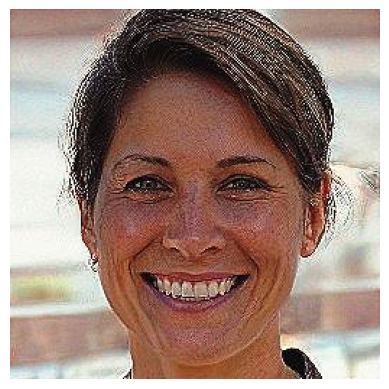

Image: X3GJMTUXZ2.jpg
Model Prediction: 'Real' confidence = 0.00%
Model Prediction: 'Fake' confidence = 100.00%



In [ ]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Function to load and preprocess an image
def load_and_preprocess_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

# Define enhanced test dataset paths
enhanced_test_dir = "/content/Dataset/enhanced_test"
categories = ["real", "fake"]

# Collect all image paths
image_paths = []
for category in categories:
    category_path = os.path.join(enhanced_test_dir, category)
    image_paths.extend([os.path.join(category_path, img) for img in os.listdir(category_path)])

# Shuffle and select 5 random images
random.shuffle(image_paths)
selected_images = image_paths[:5]

# Process and predict on the selected images
for img_path in selected_images:
    img, img_array = load_and_preprocess_image(img_path, target_size)

    # Make prediction
    prediction = model.predict(img_array)
    real_confidence = prediction[0][0] * 100
    fake_confidence = (1 - prediction[0][0]) * 100

    # Display image and results
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Model Prediction: 'Real' confidence = {real_confidence:.2f}%")
    print(f"Model Prediction: 'Fake' confidence = {fake_confidence:.2f}%\n")


In [ ]:
# Section 12: Save Model Weights
# Save model weights
model.save_weights('/content/model/weights.weights.h5')